<a href="https://colab.research.google.com/github/lricci03/Hands-on-ML/blob/main/c12/c12_food_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food classifier for c12 - ex 9

In [37]:
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

In [38]:
import torchvision
import torch
import torch.nn as nn

Connect to Google Drive

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [12]:
from pathlib import Path

DATA_DIR = Path(
    "/content/drive/MyDrive/Colab_Notebooks/Hands_On_ML_Book/c12/data"
)

print(DATA_DIR.exists())

True


In [27]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(DATA_DIR)

print(dataset.classes)
print(len(dataset))

['blackening', 'buns', 'dish', 'koji', 'miso']
499


In [79]:
dataset.classes[0]

'blackening'

## Train, Validation, Test Sets

In [29]:
from torch.utils.data import random_split

train_size = int(0.80 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

## Load the model: ResNet34

In [31]:
from torchvision.models import resnet34, ResNet34_Weights

weights = ResNet34_Weights.DEFAULT

In [33]:
weights.transforms()

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

We use the ResNet34 transform to process the images in the validation and test set.
For the train set, we do more preprocessing bc we also want to augment the set.

In [34]:
valid_transforms = weights.transforms()
test_transforms = weights.transforms()

import torchvision.transforms.v2 as T

train_transforms = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(degrees=10),
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ImageFolder(DATA_DIR, transform=train_transforms) creates a dataset from DATA_DIR containing images, and labels. The labels of an image is the folder it is in.

The transform=train_transforms applies train_transforms to the images before returning it.

We need to transform the train set differently than the validation and test sets.

Unsing Subset(): Create an ImageFolder containing all my images, with the training transform, but only give me the images whose indices are in train_dataset.indices.

In [35]:
from torch.utils.data import Subset

train = Subset(
    ImageFolder(DATA_DIR, transform=train_transforms),
    train_dataset.indices
)
valid = Subset(
    ImageFolder(DATA_DIR, transform = valid_transforms),
    val_dataset.indices
)
test = Subset(
    ImageFolder(DATA_DIR, transform = test_transforms),
    test_dataset.indices
)

## Data Loader

In [36]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid, batch_size=32)
test_loader = DataLoader(test, batch_size=32)

## Available models

In [40]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

Available resnet34 weights

In [41]:
list(torchvision.models.get_model_weights('resnet34'))

[ResNet34_Weights.IMAGENET1K_V1]

## ResNet34

In [42]:
model = torchvision.models.resnet34(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 210MB/s]


### Submodules of ResNet34

In [43]:
[name for name, child in model.named_children()]

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

In [44]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

We change the last layer: we want to classify into 5 classes

In [45]:
model.fc = nn.Linear(512, 5).to(device)

### Freeze all parameters and unfreeze only the one of the last layer

In [46]:
for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True

### Train function

In [47]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.9 MB/s eta 0:00:00


In [48]:
import torchmetrics
import time
import copy

In [52]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs, patience=10):
  train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=5).to(device)
  valid_accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=5).to(device)

  best_acc = 0.0
  best_state = None
  patience_counter = 0

  for epoch in range(n_epochs):
    model.train()
    train_accuracy.reset()
    total_loss = 0.
    t0 = time.time()

    for X_train_batch, y_train_batch in train_loader:
      X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
      y_pred = model(X_train_batch)
      loss = criterion(y_pred, y_train_batch)
      total_loss += loss.item()
      train_accuracy.update(y_pred, y_train_batch)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    epoch_accuracy = train_accuracy.compute()
    mean_loss = total_loss/len(train_loader)

    with torch.no_grad():
      model.eval()
      valid_accuracy.reset()

      for X_valid_batch, y_valid_batch in valid_loader:
        X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
        y_valid_pred = model(X_valid_batch)
        valid_accuracy.update(y_valid_pred, y_valid_batch)
      epoch_valid_accuracy = valid_accuracy.compute()

      # we save the best model. We don't stop if validation decresaes bc w/ mini-batch sometimes accuracy decreases but then increases again.
      if epoch_valid_accuracy > best_acc:
        best_acc = epoch_valid_accuracy
        best_state = copy.deepcopy(model.state_dict())
        #patience_counter = 0
      #else:
      #  patience_counter +=1

    #if patience_counter == patience:
    #  print(f'Early stopping')
    #  break
    t1 = time.time()

    print(f'Epoch {epoch + 1}/{n_epochs}: Train Loss: {mean_loss:.4f} Train Accuracy: {epoch_accuracy:.4f}, Validation Accuracy: {epoch_valid_accuracy:.4f}'
          f'in {t1-t0:.1f}s')
  if best_state is not None:
    model.load_state_dict(best_state)

  return model, best_acc



### Optimizer, loss function, metric & train the model

In [53]:
learning_rate = 0.001
betas = (0.9, 0.999)
optimizer = torch.optim.NAdam(model.parameters(), betas = betas, lr = learning_rate)
xentropy = nn.CrossEntropyLoss()

In [54]:
best_model, best_acc = train(model,optimizer,xentropy,train_loader,valid_loader, n_epochs=5)

Epoch 1/5: Train Loss: 1.6272 Train Accuracy: 0.2682, Validation Accuracy: 0.3673in 7.6s
Epoch 2/5: Train Loss: 1.2471 Train Accuracy: 0.5338, Validation Accuracy: 0.5510in 5.4s
Epoch 3/5: Train Loss: 0.9509 Train Accuracy: 0.7794, Validation Accuracy: 0.6531in 6.8s
Epoch 4/5: Train Loss: 0.7801 Train Accuracy: 0.7945, Validation Accuracy: 0.6327in 5.4s
Epoch 5/5: Train Loss: 0.6769 Train Accuracy: 0.8496, Validation Accuracy: 0.7551in 6.4s


In [55]:
best_model, best_acc = train(model,optimizer,xentropy,train_loader,valid_loader, n_epochs=5)

Epoch 1/5: Train Loss: 0.5778 Train Accuracy: 0.8847, Validation Accuracy: 0.8163in 5.4s
Epoch 2/5: Train Loss: 0.5143 Train Accuracy: 0.8822, Validation Accuracy: 0.8163in 8.6s
Epoch 3/5: Train Loss: 0.4653 Train Accuracy: 0.8922, Validation Accuracy: 0.8163in 6.1s
Epoch 4/5: Train Loss: 0.4168 Train Accuracy: 0.9123, Validation Accuracy: 0.7959in 7.2s
Epoch 5/5: Train Loss: 0.4058 Train Accuracy: 0.8972, Validation Accuracy: 0.8367in 5.8s


Unfreeze the previous layers

In [56]:
for param in model.parameters():
  param.requires_grad = True

In [57]:
optimizer = torch.optim.NAdam(model.parameters(), betas = betas, lr = 0.0001)

In [58]:
best_model, best_acc = train(model,optimizer,xentropy,train_loader,valid_loader, n_epochs=5)

Epoch 1/5: Train Loss: 0.3240 Train Accuracy: 0.9148, Validation Accuracy: 0.8776in 5.7s
Epoch 2/5: Train Loss: 0.0620 Train Accuracy: 0.9925, Validation Accuracy: 0.9388in 6.1s
Epoch 3/5: Train Loss: 0.0420 Train Accuracy: 0.9900, Validation Accuracy: 0.9184in 5.2s
Epoch 4/5: Train Loss: 0.0395 Train Accuracy: 0.9875, Validation Accuracy: 0.9388in 6.9s
Epoch 5/5: Train Loss: 0.0377 Train Accuracy: 0.9900, Validation Accuracy: 0.9388in 5.4s


### Accuracy on the test set

In [59]:
test_accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=5).to(device)

with torch.no_grad():
  best_model.eval()

  for X_test_batch, y_test_batch in test_loader:
    X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)
    y_test_pred = best_model(X_test_batch)
    test_accuracy.update(y_test_pred, y_test_batch)
  accuracy = test_accuracy.compute()

print(accuracy)

tensor(0.9020, device='cuda:0')


### Visualize mistakes

Test images: 51
Wrong predictions: 5


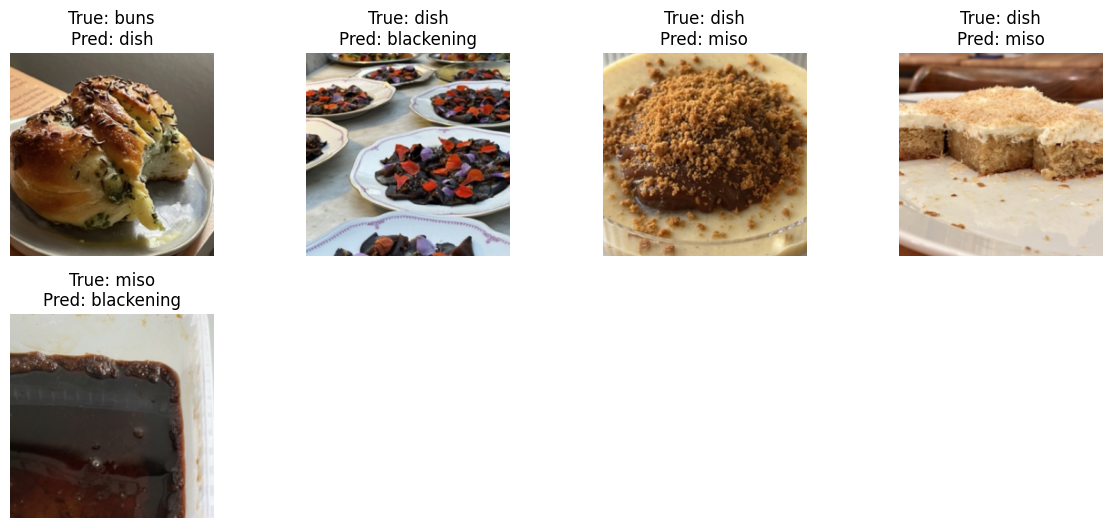

In [61]:
import matplotlib.pyplot as plt

all_images = []
all_labels = []
all_predictions = []

best_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        predictions = best_model(images).argmax(dim=1)

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())

images = torch.cat(all_images)
labels = torch.cat(all_labels)
predictions = torch.cat(all_predictions)

wrong = predictions != labels

wrong_images = images[wrong]
wrong_labels = labels[wrong]
wrong_predictions = predictions[wrong]

print(f"Test images: {len(images)}")
print(f"Wrong predictions: {len(wrong_images)}")

mean = torch.tensor([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).reshape(3, 1, 1)

n = min(12, len(wrong_images))

plt.figure(figsize=(12, 8))

for i in range(n):

    image = wrong_images[i] * std + mean

    plt.subplot(3, 4, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1))

    plt.title(
        f"True: {classes[wrong_labels[i]]}\n"
        f"Pred: {classes[wrong_predictions[i]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
print(len(test))

51


## Predict a new image

In [72]:
image = Path(
    "/content/drive/MyDrive/Colab_Notebooks/Hands_On_ML_Book/c12/IMG_1352.jpeg"
)
print(image.exists())

True


We need to transform the new image so that the model can evalate it: The weight.transforms() method expects a PIL image. Before, jpeg -> PIL was performed by ImageFolder(). Here we need to use PIL.Image.open()

After transforming, we need to adjust dimensions: the transformed image is 3 x 224 x 224, but the model needs 1 x 3 x 224 x 224.

This is done with processed_image.unsqueeze(0)

In [73]:
from PIL import Image

image = Image.open(image)
processed_new_image = test_transforms(image).unsqueeze(0).to(device)

In [76]:
best_model.eval()
with torch.no_grad():
  y_logits = best_model(processed_new_image)
  y_pred = torch.argmax(y_logits, dim=1)

In [80]:
print(dataset.classes[y_pred.item()])

koji


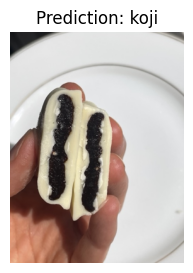

In [83]:
plt.figure(figsize=(4, 3))
plt.imshow(image)
plt.title(f'Prediction: {dataset.classes[y_pred.item()]}')
plt.axis('off')
plt.show()

In [104]:
y_logits

tensor([[ 0.8580, -1.8098,  0.4208,  1.0168, -2.4214]], device='cuda:0')

In [105]:
y_logits[0]

tensor([ 0.8580, -1.8098,  0.4208,  1.0168, -2.4214], device='cuda:0')

In [100]:
dataset.class_to_idx

{'blackening': 0, 'buns': 1, 'dish': 2, 'koji': 3, 'miso': 4}

In [102]:
cls_to_idx = dataset.class_to_idx

In [115]:
for cls in cls_to_idx:
  print(f'{cls} logit: {y_logits[0][cls_to_idx[cls]]:.2f}')

blackening logit: 0.86
buns logit: -1.81
dish logit: 0.42
koji logit: 1.02
miso logit: -2.42


## Predict a folder of new images

In [85]:
new_images = Path(
    "/content/drive/MyDrive/Colab_Notebooks/Hands_On_ML_Book/c12/new_images"
)
print(new_images.exists())

True


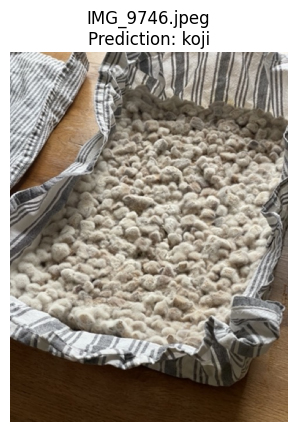

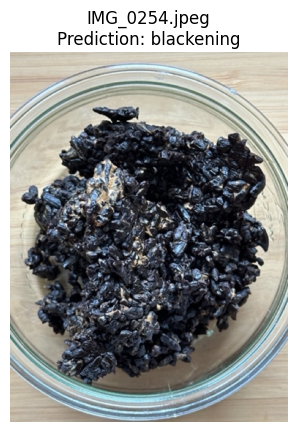

In [86]:
import matplotlib.pyplot as plt
from PIL import Image

best_model.eval()

for image_path in new_images.glob("*.jpeg"):

    image = Image.open(image_path)

    processed_image = test_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = best_model(processed_image).argmax(dim=1).item()

    plt.imshow(image)
    plt.title(f"{image_path.name}\nPrediction: {dataset.classes[prediction]}")
    plt.axis("off")
    plt.show()

##